## 3. Modeling TF-IDF x LSTM

### 3.1 Importing the Libraries 

In [1]:
import pickle
import os 
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, LSTM, Input, Concatenate 
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Dense, Embedding, LSTM, # <-- Hanya LSTM, bukan BiLSTM
    Input, Concatenate, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam # <-- Import Adam


2025-11-17 11:47:03.055716: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-17 11:47:03.056210: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-17 11:47:03.119191: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-17 11:47:04.679963: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
MODEL_SAVE_PATH = "../models/lstm_model.keras"

### 3.2 Define the Parameter

In [3]:
VOCAB_SIZE = 5000
TFIDF_FEATURES = 5000
MAX_LEN = 200

### 3.2 Load the Dataset

In [4]:
X_train_pad   = pickle.load(open("../dataset/processed/02_after_FE/X_train_pad.pkl", "rb"))
X_train_tfidf = pickle.load(open("../dataset/processed/02_after_FE/X_train_tfidf.pkl", "rb"))
y_train       = pickle.load(open("../dataset/processed/02_after_FE/y_train.pkl", "rb"))

X_test_pad    = pickle.load(open("../dataset/processed/02_after_FE/X_test_pad.pkl", "rb"))
X_test_tfidf  = pickle.load(open("../dataset/processed/02_after_FE/X_test_tfidf.pkl", "rb"))
y_test        = pickle.load(open("../dataset/processed/02_after_FE/y_test.pkl", "rb"))

### 3.3 Check Array Dimension

In [5]:
print(f"Shape X_train_pad: {X_train_pad.shape}")
print(f"Shape X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape y_test: {y_test.shape}")

Shape X_train_pad: (16479, 200)
Shape X_train_tfidf: (30432, 5000)
Shape y_train: (30432,)
Shape y_test: (4120,)


### 3.4 Build LSTM Model with TF-IDF

In [6]:
# sequence for lstm
input_seq = Input(shape=(MAX_LEN,), name='input_sequence')
x = Embedding(input_dim=VOCAB_SIZE, output_dim=128)(input_seq) 

x = LSTM(32)(x) 

x = Dropout(0.5)(x) 

# vektor TD-IDF
input_tfidf = Input(shape=(TFIDF_FEATURES,), name='input_tfidf') 
y = Dense(16, activation='relu')(input_tfidf) 

# concate
combined = Concatenate()([x, y])

# output layer
z = Dense(32, activation="relu")(combined) 
z = Dropout(0.5)(z) 
output_layer = Dense(1, activation="sigmoid")(z)

# define model
model = Model(inputs=[input_seq, input_tfidf], outputs=output_layer)

optimizer = Adam(learning_rate=0.0001)

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer, 
    metrics=['accuracy']
)
print(model.summary())

E0000 00:00:1763354826.832054   93726 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1763354826.842543   93726 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │    640,000 │ input_sequence[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │     20,608 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_tfidf         │ (None, 5000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     80,016 │ input_tfidf[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,568 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 742,225 (2.83 MB)

 Trainable params: 742,225 (2.83 MB)

 Non-trainable params: 0 (0.00 B)

None


### 3.5 Define Callbacks

In [7]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

### 3.6 Training

In [8]:
history = model.fit(
    [X_train_pad, X_train_tfidf],
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.8866 - loss: 0.4728 - val_accuracy: 0.9342 - val_loss: 0.1547
Epoch 2/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.9501 - loss: 0.1469 - val_accuracy: 0.9712 - val_loss: 0.0841
Epoch 3/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - accuracy: 0.9739 - loss: 0.0883 - val_accuracy: 0.9736 - val_loss: 0.0750
Epoch 4/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.9866 - loss: 0.0735 - val_accuracy: 0.9833 - val_loss: 0.0583
Epoch 5/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.9923 - loss: 0.0524 - val_accuracy: 0.9860 - val_loss: 0.0529
Epoch 6/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.9954 - loss: 0.0377 - val_accuracy: 0.9863 - val_loss: 0.0533
Epoch 7/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.9970 - loss: 0.0285 - val_accuracy: 0.9873 - val_loss: 0.0431
Epoch 8/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.9981 - loss: 0.0207 - 

### 3.7 Evaluation

In [9]:
loss, acc = model.evaluate([X_test_pad, X_test_tfidf], y_test, verbose=1)
print(f"\nAkurasi Test (LSTM + TF-IDF): {acc:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9840 - loss: 0.0543

Akurasi Test (LSTM + TF-IDF): 0.9840


Membuat plot training & validation loss...


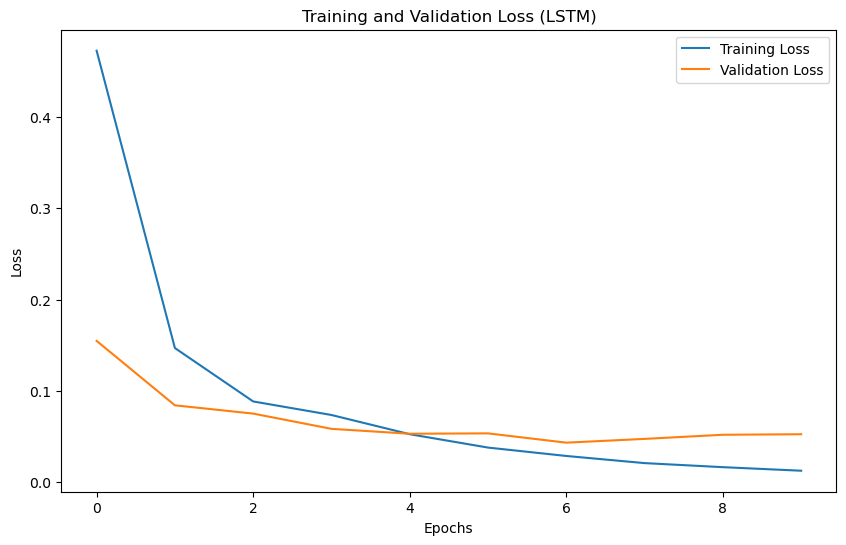

In [10]:
print("Membuat plot training & validation loss...")
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (LSTM)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### 3.8 Save Model

In [11]:
os.makedirs("models", exist_ok=True)
model.save(MODEL_SAVE_PATH)
print("Model LSTM saved to:", MODEL_SAVE_PATH)

Model LSTM saved to: ../models/lstm_model.keras
